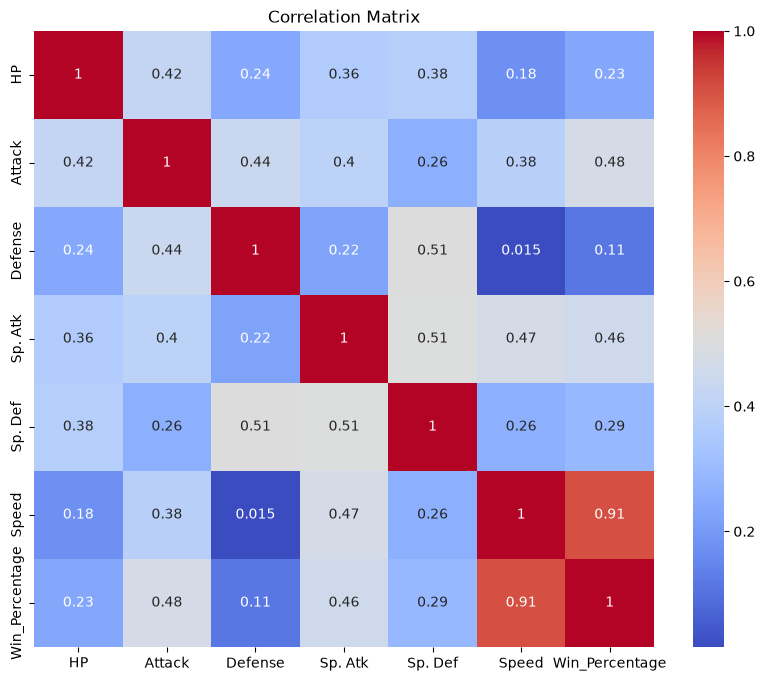

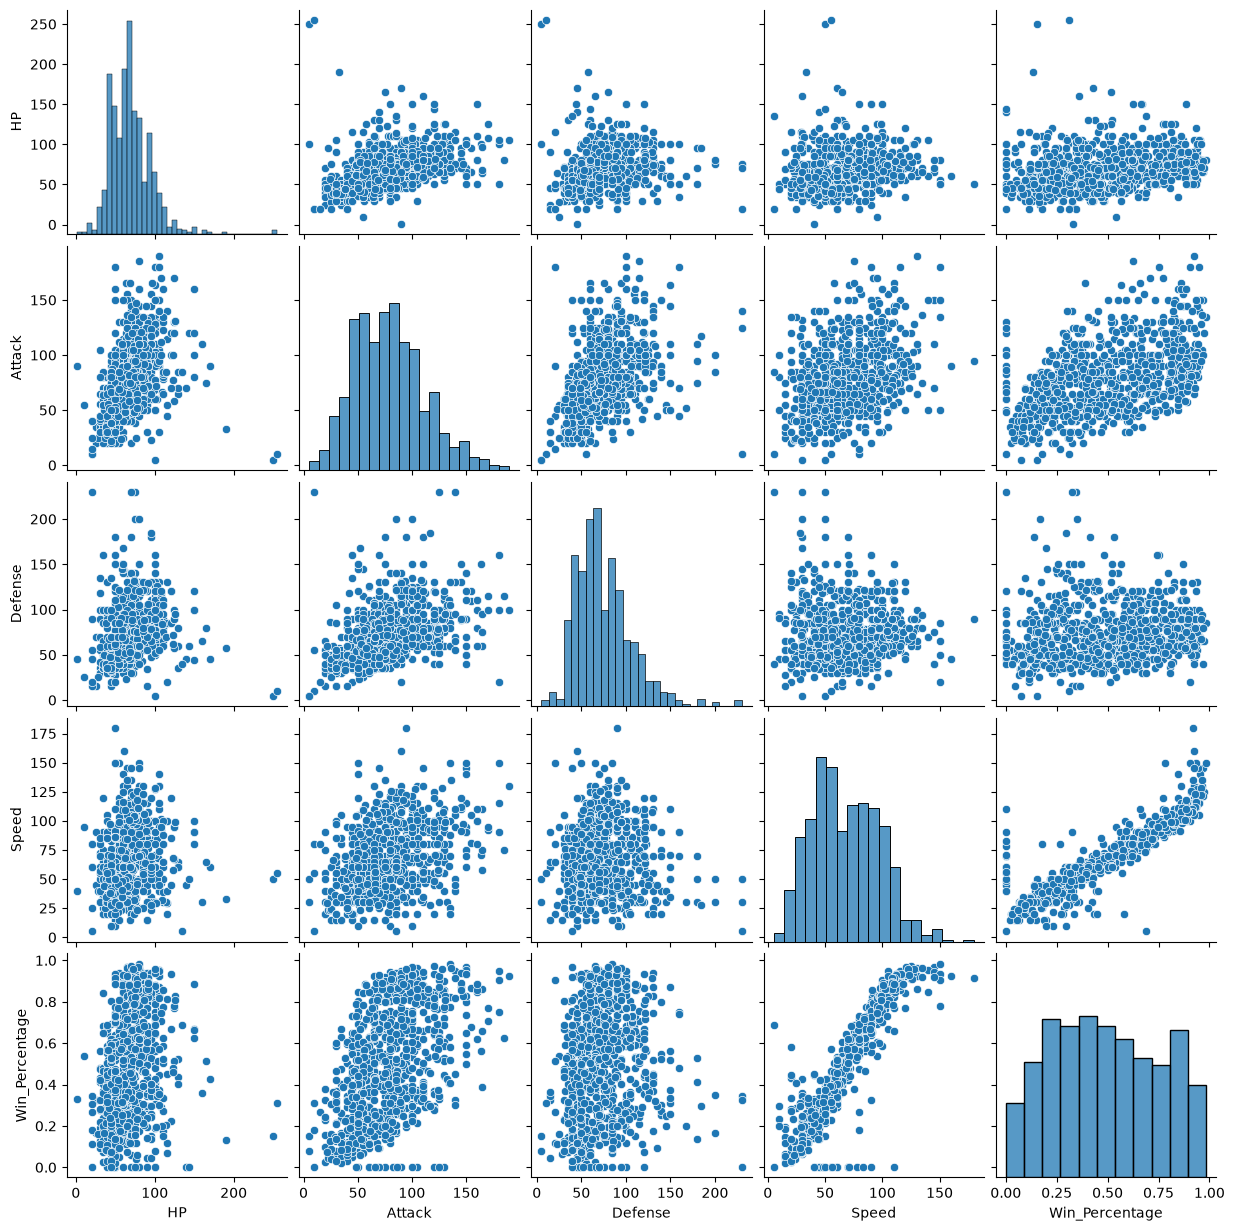


TOP 10 POKEMON BY WIN PERCENTAGE

                         Name   Type 1   HP  Attack  Defense  Speed  \
154           Mega Aerodactyl     Rock   80     135       85    150   
512                   Weavile     Dark   70     120       65    125   
703    Tornadus Therian Forme   Flying   79     100       80    121   
19              Mega Beedrill      Bug   65     150       40    145   
153                Aerodactyl     Rock   80     105       65    130   
476              Mega Lopunny   Normal   65     136       94    135   
726                  Greninja    Water   72      95       67    122   
716  Meloetta Pirouette Forme   Normal  100     128       90    128   
164             Mega Mewtwo Y  Psychic  106     150       70    140   
349             Mega Sharpedo    Water   70     140       70    105   

     Win_Percentage  
154        0.984496  
512        0.974790  
703        0.968000  
19         0.966387  
153        0.964539  
476        0.961240  
726        0.960630  
716    

In [1]:
# ============================================================
# DAILY CHALLENGE : POKEMON WIN PREDICTION ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 2. LOAD DATASETS
# ------------------------------------------------------------
pokemon = pd.read_csv("pokemon.csv")
combats = pd.read_csv("combats.csv")

# ------------------------------------------------------------
# 3. FIX MISSING VALUES
# Fill missing name for Pokemon #63 (Primeape)
# ------------------------------------------------------------
pokemon.loc[pokemon["#"] == 63, "Name"] = "Primeape"

# ------------------------------------------------------------
# 4. HANDLE MISSING VALUES IN TYPE 2
# ------------------------------------------------------------
pokemon["Type 2"] = pokemon["Type 2"].fillna("None")

# ------------------------------------------------------------
# 5. CALCULATE WIN PERCENTAGE
# ------------------------------------------------------------

# Count victories
wins = combats["Winner"].value_counts().reset_index()
wins.columns = ["#", "Wins"]

# Count battles played
all_battles = pd.concat([
    combats["First_pokemon"],
    combats["Second_pokemon"]
])

battles = all_battles.value_counts().reset_index()
battles.columns = ["#", "Battles"]

# Merge battle statistics
battle_stats = battles.merge(wins, on="#", how="left")
battle_stats["Wins"] = battle_stats["Wins"].fillna(0)

# Win percentage
battle_stats["Win_Percentage"] = (
    battle_stats["Wins"] / battle_stats["Battles"]
)

# ------------------------------------------------------------
# 6. MERGE POKEMON DATA WITH WIN PERCENTAGE
# ------------------------------------------------------------
df = pokemon.merge(
    battle_stats[["#", "Win_Percentage"]],
    on="#",
    how="left"
)

df["Win_Percentage"] = df["Win_Percentage"].fillna(0)

# ------------------------------------------------------------
# 7. CORRELATION MATRIX
# ------------------------------------------------------------
corr_features = [
    "HP",
    "Attack",
    "Defense",
    "Sp. Atk",
    "Sp. Def",
    "Speed",
    "Win_Percentage"
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    df[corr_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# ------------------------------------------------------------
# 8. PAIRPLOT OF STATS VS WIN PERCENTAGE
# ------------------------------------------------------------
sns.pairplot(
    df[
        [
            "HP",
            "Attack",
            "Defense",
            "Speed",
            "Win_Percentage"
        ]
    ]
)

plt.show()

# ------------------------------------------------------------
# 9. TOP 10 POKEMON BY WIN PERCENTAGE
# ------------------------------------------------------------
top10 = (
    df.sort_values(
        by="Win_Percentage",
        ascending=False
    )
    [["Name",
      "Type 1",
      "HP",
      "Attack",
      "Defense",
      "Speed",
      "Win_Percentage"]]
    .head(10)
)

print("\nTOP 10 POKEMON BY WIN PERCENTAGE\n")
print(top10)

# ------------------------------------------------------------
# 10. PREPARE DATA FOR MACHINE LEARNING
# ------------------------------------------------------------

# Convert categorical variables
ml_df = pd.get_dummies(
    df,
    columns=["Type 1", "Type 2"],
    drop_first=True
)

# Convert Legendary to integer
ml_df["Legendary"] = ml_df["Legendary"].astype(int)

# Drop non-useful columns
X = ml_df.drop(
    columns=[
        "#",
        "Name",
        "Win_Percentage"
    ]
)

y = ml_df["Win_Percentage"]

# ------------------------------------------------------------
# 11. TRAIN / TEST SPLIT (80/20)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------------------------
# 12. LINEAR REGRESSION
# ------------------------------------------------------------
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

# ------------------------------------------------------------
# 13. RANDOM FOREST REGRESSION
# ------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

# ------------------------------------------------------------
# 14. PCA + LINEAR REGRESSION
# ------------------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_lr = LinearRegression()

pca_lr.fit(
    X_train_pca,
    y_train
)

pca_pred = pca_lr.predict(
    X_test_pca
)

pca_mae = mean_absolute_error(
    y_test,
    pca_pred
)

# ------------------------------------------------------------
# 15. COMPARE MODEL PERFORMANCE
# ------------------------------------------------------------
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "PCA + Linear Regression"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        pca_mae
    ]
})

print("\nMODEL COMPARISON\n")
print(results.sort_values("MAE"))

# ------------------------------------------------------------
# 16. BEST MODEL
# ------------------------------------------------------------
best_model = results.loc[
    results["MAE"].idxmin()
]

print("\nBEST MODEL:")
print(best_model)